# Import, config and load data

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import *

from darts import TimeSeries
from darts.dataprocessing.transformers import WindowTransformer, StaticCovariatesTransformer

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

import os
# -------------------- CONFIG --------------------
DATA_FOLDER       = "./data"
FIXED_DATA_PATH   = construct_path(DATA_FOLDER, "fixed")
DATASET_PATH      = construct_path(DATA_FOLDER, "dataset")

TARGET_RAW_EVENT_CLASSIFIER        = "act_drone_strike_on_ua"          # count target
TARGET_EVENT_CLASSIFIER            = "act_drone_strike_on_ua_binary"   # binary target
TARGET_REGRESSOR = TARGET_RAW_EVENT_CLASSIFIER

# Forecasting setup
OUTPUT_CHUNK_LEN  = 7      # how many days ahead each model predicts in one shot
INPUT_LAGS        = 7      # how many past days of the target the model sees
MULTI_MODELS      = True   # direct strategy: one sub-model per horizon step

# CV / split
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.10, 0.20   # enforced by split_series_list
CV_STRIDE                       = 1                   # For final evaluation No weekly stride, new forecast everyday


available_threads = get_available_threads()
print(f'CPU count: {available_threads}')

RANDOM_STATE      = 42
np.random.seed(RANDOM_STATE)

CPU count: 16


In [3]:
regions,master_timeseries,regions_activity = \
    load_data(data_path=FIXED_DATA_PATH,dataset_path=DATASET_PATH)

master_timeseries shape: (847, 1622)
regions: 25  -  ['cherkasy', 'chernihiv', 'chernivtsi', 'dnipropetrovsk', 'donetsk'] ...
start: 2022-09-28 00:00:00 end: 2025-01-21 00:00:00


In [4]:
# For regressor
for_global_REGRESSOR, global_weather_columns = get_engineered_features(
    master_timeseries=master_timeseries,
    data_path=FIXED_DATA_PATH,
    target_col=TARGET_REGRESSOR,
    regions=regions,
    regions_activity=regions_activity,
    binarize_target=False
)
#For event_classifier
for_global_EVENT_CLASSIFIER, _ = get_engineered_features(
    master_timeseries=master_timeseries,
    data_path=FIXED_DATA_PATH,
    target_col=TARGET_EVENT_CLASSIFIER, 
    regions=regions,
    regions_activity=regions_activity,
    binarize_target=True,
    target_raw_col=TARGET_RAW_EVENT_CLASSIFIER
)

Shape after feature engineering: (16940, 115)
Target mean: 0.394
Shape after feature engineering: (16940, 115)
Target positive rate: 0.144


In [5]:
# For event_classifier
holiday_cols_c, future_covariates_c, exclude_cols_c, past_covariates_c = split_future_and_past_cov(for_global_EVENT_CLASSIFIER,global_weather_columns,TARGET_EVENT_CLASSIFIER)
# For regressor
holiday_cols_r, future_covariates_r, exclude_cols_r, past_covariates_r = split_future_and_past_cov(for_global_REGRESSOR,global_weather_columns,TARGET_REGRESSOR)

# future covariates : 27
# past covariates   : 85
# future covariates : 27
# past covariates   : 85


### Building timeseries objects

In [6]:
# For event_classifier
target_series_list_c, past_covs_list_c,future_covs_list_c =build_ts_and_apply_window_transformer(
                                            for_global_EVENT_CLASSIFIER,
                                            TARGET_EVENT_CLASSIFIER,
                                            past_covariates_c,
                                            future_covariates_c,
                                            ed_alpha=halflife_to_alpha(7)
                                            )
# For regressor
target_series_list_r, past_covs_list_r,future_covs_list_r =build_ts_and_apply_window_transformer(
                                            for_global_REGRESSOR,
                                            TARGET_REGRESSOR,
                                            past_covariates_r,
                                            future_covariates_r,
                                            ed_alpha=halflife_to_alpha(7)
                                            )

Past-cov components: raw=85  transformed=595
Past-cov components: raw=85  transformed=595


In [7]:
# For event_classifier
region_names, train_target_c, val_target_c, test_target_c, full_past_covs_c, full_fut_covs_c, target_for_cv_c, TRAIN_VAL_END,CV_START_VAL =\
      get_covs_and_encodings(target_series_list_c,past_covs_list_c,future_covs_list_c,TRAIN_FRAC,VAL_FRAC)

# For regressor
_, train_target_r, val_target_r, test_target_r, full_past_covs_r, full_fut_covs_r, target_for_cv_r, _,_ =\
      get_covs_and_encodings(target_series_list_r,past_covs_list_r,future_covs_list_r,TRAIN_FRAC,VAL_FRAC)

# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only
# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only


### Building the classifier and regressors themselves

In [15]:
from darts.models import LightGBMModel,LightGBMClassifierModel,SKLearnClassifierModel,CatBoostModel
from imbens.ensemble import SelfPacedEnsembleClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

COMMON_KWARGS = get_common_kwargs()

# We can use calibration with Venn- ABERS here or use posthoc calibration with platt 
def get_event_classifier(**kwargs):
    DTm_depth = kwargs.get('DTm_depth',5)
    SPE_estm = kwargs.get('SPE_estm',100)
    clf = SelfPacedEnsembleClassifier(
        estimator    = DecisionTreeClassifier(
            max_depth=DTm_depth, 
            random_state=RANDOM_STATE
            ),
        n_estimators = SPE_estm,                
        random_state = RANDOM_STATE,
        n_jobs       = available_threads,
    )

    return SKLearnClassifierModel(model=clf, **COMMON_KWARGS)

def get_count_regressor(**kwargs):
        return CatBoostModel(
            **COMMON_KWARGS,
            loss_function     = "Tweedie:variance_power=1.5",
            boost_from_average= False,
            random_seed       = RANDOM_STATE,
            task_type         = "CPU",
            thread_count = available_threads,
            **kwargs
        )

event_classifier_feature_selection =  LightGBMClassifierModel(
            **COMMON_KWARGS,
            objective         = "binary",
            is_unbalance      = True,
            random_state      = RANDOM_STATE,
        )

regressor_feature_selection = LightGBMModel(
            **COMMON_KWARGS,
            objective         = "poisson",
            random_state      = RANDOM_STATE,
        )



In [9]:
# Train on positive samples only
full_weights = make_positive_only_weights(target_series_list_r)
# For regressor
regressor_feature_selection.fit(
    series            = train_target_r,
    past_covariates   = full_past_covs_r,
    future_covariates =  full_fut_covs_r,
    sample_weight     = [w.slice_intersect(ts) for w, ts in zip(full_weights, train_target_r)],
)


top_100_features_r = get_top_100_from_lgbm(regressor_feature_selection)
top_100_features_dict_r = clean_feature_names(top_100_features_r)

# For classifier
event_classifier_feature_selection.fit(
    series          = train_target_c,
    past_covariates = full_past_covs_c,
    future_covariates = full_fut_covs_c,
)

top_100_features_c = get_top_100_from_lgbm(event_classifier_feature_selection)
top_100_features_dict_c = clean_feature_names(top_100_features_c)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.189885 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299717
[LightGBM] [Info] Number of data points in the train set: 11460, number of used features: 2097
[LightGBM] [Info] Start training from score 0.665190
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299717
[LightGBM] [Info] Number of data points in the train set: 11460, number of used features: 2097
[LightGBM] [Info] Start training from score 0.667159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.152542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 299717
[LightGBM] [Info] Number of data points in the train set: 11460, number of used features: 2097
[LightGBM] [Inf

In [10]:
# For classifier
past_covs_list_c   = [subset_safe(ts, top_100_features_dict_c['pastcov_features_base']) for ts in past_covs_list_c]
future_covs_list_c = [subset_safe(ts, top_100_features_dict_c['futcov_features_base'])  for ts in future_covs_list_c]
_, train_target_c, val_target_c, test_target_c, full_past_covs_c, full_fut_covs_c, target_for_cv_c,TRAIN_VAL_END,CV_START_VAL = \
    get_covs_and_encodings(target_series_list_c,past_covs_list_c,future_covs_list_c,TRAIN_FRAC,VAL_FRAC)

# For Regressor
past_covs_list_r   = [subset_safe(ts, top_100_features_dict_r['pastcov_features_base']) for ts in past_covs_list_r]
future_covs_list_r = [subset_safe(ts, top_100_features_dict_r['futcov_features_base'])  for ts in future_covs_list_r]
_, train_target_r, val_target_r, test_target_r, full_past_covs_r, full_fut_covs_r, target_for_cv_r,_,_ = \
    get_covs_and_encodings(target_series_list_r,past_covs_list_r,future_covs_list_r,TRAIN_FRAC,VAL_FRAC)

# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only
# regions: 20
train len (region 0): 593 days
val   len (region 0): 85 days
test  len (region 0): 169 days  <- untouched until the final evaluation
CV view length       : 676 days (train+val)
CV start on that view: 0.875  -> rolls across the val segment only


# Predictions;
- Probability that event happends (i.e. probabilistic output of classifier) $\hat{\pi}(x) = P(Y > 0 | X)$ 

- The count of the events given that it happends $\hat{\mu}(x) = E(Y | X,Y > 0)$ 

- Final estimate $\hat{E}(Y|X) = \hat{\pi}(x) \cdot \hat{\mu}(x)$ 
- y_pred ($\hat{y} = \hat{E}(Y|X)$)

## Cross-Validation

In [33]:
from sklearn.metrics import r2_score
# from src import base_metrics, _scaled_metrics  # not re-exported by import *


def _hurdle_metrics(y_true, y_pred):
    """base_metrics (from src) extended with R²."""
    base = base_metrics(y_true, y_pred)
    y_true_arr = np.asarray(y_true, dtype=float).ravel()
    y_pred_arr = np.clip(np.asarray(y_pred, dtype=float).ravel(), 0.0, None)
    base["R2"] = float(r2_score(y_true_arr, y_pred_arr))
    return base


def evaluate_hurdle_long(long_df, mae_scales, rmse_scales):
    """evaluate_long extended with R². mae_scales/rmse_scales from compute_naive_scales."""
    def _rows_from_groupby(group_cols):
        rows = []
        for keys, sub in long_df.groupby(group_cols):
            row = _hurdle_metrics(sub["y_true"], sub["y_pred"])
            key_map = (
                {group_cols: keys} if isinstance(group_cols, str)
                else dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
            )
            region_key = key_map.get("region")
            if region_key is not None:
                row.update(_scaled_metrics(sub, mae_scales.get(region_key), rmse_scales.get(region_key)))
            elif "region" in sub.columns:
                # Average per-region MASE/RMSSE across regions within this group
                mase_vals, rmsse_vals = [], []
                for reg, reg_sub in sub.groupby("region"):
                    sm = _scaled_metrics(reg_sub, mae_scales.get(reg), rmse_scales.get(reg))
                    if not np.isnan(sm["MASE"]):
                        mase_vals.append(sm["MASE"])
                    if not np.isnan(sm["RMSSE"]):
                        rmsse_vals.append(sm["RMSSE"])
                row["MASE"]  = float(np.mean(mase_vals))  if mase_vals  else np.nan
                row["RMSSE"] = float(np.mean(rmsse_vals)) if rmsse_vals else np.nan
            row.update(key_map)
            rows.append(row)
        return pd.DataFrame(rows)

    per_region         = _rows_from_groupby("region").sort_values("MASE", ascending=True).reset_index(drop=True)
    per_horizon        = _rows_from_groupby("horizon").sort_values("horizon").reset_index(drop=True)
    per_region_horizon = _rows_from_groupby(["region", "horizon"]).sort_values(["region", "horizon"]).reset_index(drop=True)
    global_row = _hurdle_metrics(long_df["y_true"], long_df["y_pred"])
    global_row["MASE_mean"]   = float(per_region["MASE"].mean())
    global_row["MASE_median"] = float(per_region["MASE"].median())
    global_row["RMSSE_mean"]  = float(per_region["RMSSE"].mean())
    return {"per_region": per_region, "per_horizon": per_horizon,
            "per_region_horizon": per_region_horizon, "global": global_row}


def _classif_metrics_hurdle(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    def _safe(fn_):
        try: return float(fn_())
        except (ValueError, ZeroDivisionError): return np.nan
    return {
        "F1":        _safe(lambda: f1_score(y_true, y_pred, zero_division=0)),
        "Precision": _safe(lambda: precision_score(y_true, y_pred, zero_division=0)),
        "Recall":    _safe(lambda: recall_score(y_true, y_pred, zero_division=0)),
        "ROC_AUC":   _safe(lambda: roc_auc_score(y_true, y_prob)),
        "PR_AUC":    _safe(lambda: average_precision_score(y_true, y_prob)),
        "Brier":     _safe(lambda: brier_score_loss(y_true, y_prob)),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn), "n": int(len(y_true)),
    }


def evaluate_classif_long(long_df, threshold=0.5):
    def _rows(group_cols):
        rows = []
        for keys, sub in long_df.groupby(group_cols):
            m = _classif_metrics_hurdle(sub["y_true"], sub["y_prob"], threshold)
            key_map = (
                {group_cols: keys} if isinstance(group_cols, str)
                else dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
            )
            m.update(key_map)
            rows.append(m)
        return pd.DataFrame(rows)
    return {
        "per_region":         _rows("region").sort_values("F1", ascending=False).reset_index(drop=True),
        "per_horizon":        _rows("horizon").sort_values("horizon").reset_index(drop=True),
        "per_region_horizon": _rows(["region", "horizon"]).sort_values(["region", "horizon"]).reset_index(drop=True),
        "global":             _classif_metrics_hurdle(long_df["y_true"], long_df["y_prob"], threshold),
    }


In [16]:
def run_hurdle_cv(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Expanding-window CV for the hurdle model.

    Makes a 7-day prediction every predict_stride days (default: every day).
    Retrains both models every retrain_stride days (default: every 7 days).
    The frozen model handles all daily predictions within each retrain window,
    but predict() is called with a growing context series each day:

        x * * * * * * *          <- predict day 0  (model trained at day 0)
        ...
        x x x x x x x * * * * * * *  <- predict day 6 then RETRAIN
        x x x x x x x x * * * * * * *  <- predict day 7 (new model)

    Returns
    -------
    fold_preds_c : list[list[TimeSeries]]  P(Y>0) per region / prediction day
    fold_preds_r : list[list[TimeSeries]]  E(Y|Y>0) per region / prediction day
    fold_preds_h : list[list[TimeSeries]]  hurdle = prob * count
    """
    ref_ts    = target_for_cv_c[0]
    n_total   = len(ref_ts)
    start_idx = int(CV_START_VAL * n_total)
    n_regions = len(target_for_cv_c)

    fold_preds_c = [[] for _ in range(n_regions)]
    fold_preds_r = [[] for _ in range(n_regions)]
    fold_preds_h = [[] for _ in range(n_regions)]
    n_preds    = 0
    n_retrains = 0
    clf = None
    reg = None

    for t0 in range(start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
        steps_since_start = t0 - start_idx

        # --- Retrain every retrain_stride steps ---
        if steps_since_start % retrain_stride == 0:
            retrain_time  = ref_ts.time_index[t0]
            train_c       = [ts.drop_after(retrain_time) for ts in target_for_cv_c]
            train_r       = [ts.drop_after(retrain_time) for ts in target_for_cv_r]
            train_weights = [w.drop_after(retrain_time)  for w  in full_weights]

            clf = get_event_classifier()
            clf.fit(series=train_c, past_covariates=full_past_covs_c,
                    future_covariates=full_fut_covs_c)

            reg = get_count_regressor()
            reg.fit(series=train_r, past_covariates=full_past_covs_r,
                    future_covariates=full_fut_covs_r, sample_weight=train_weights)

            n_retrains += 1
            print(f"   retrain {n_retrains}  (data up to {retrain_time.date()})")

        # --- Daily prediction: growing context, frozen model ---
        split_time    = ref_ts.time_index[t0]
        pred_series_c = [ts.drop_after(split_time) for ts in target_for_cv_c]
        pred_series_r = [ts.drop_after(split_time) for ts in target_for_cv_r]

        preds_c = clf.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_c,
            past_covariates=full_past_covs_c, future_covariates=full_fut_covs_c,
            predict_likelihood_parameters=True, show_warnings=False,
        )
        preds_r = reg.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_r,
            past_covariates=full_past_covs_r, future_covariates=full_fut_covs_r,
            show_warnings=False,
        )

        for r_idx, (pred_c, pred_r) in enumerate(zip(preds_c, preds_r)):
            prob_ts = pred_c.univariate_component(pred_c.n_components - 1)
            probs   = prob_ts.values().ravel()
            counts  = pred_r.values().ravel()
            hurdle_ts = TimeSeries.from_times_and_values(
                pred_r.time_index, (probs * counts).reshape(-1, 1)
            )
            fold_preds_c[r_idx].append(prob_ts)
            fold_preds_r[r_idx].append(pred_r)
            fold_preds_h[r_idx].append(hurdle_ts)

        n_preds += 1

    print(f"   {n_preds} daily predictions, {n_retrains} retrains complete")
    return fold_preds_c, fold_preds_r, fold_preds_h


In [17]:
print("Running hurdle CV ...")
fold_preds_c, fold_preds_r, fold_preds_h = run_hurdle_cv()

# collect_predictions_long uses y_pred column; rename to y_prob for the classifier
long_df_c = (
    collect_predictions_long(target_for_cv_c, fold_preds_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
long_df_r = collect_predictions_long(target_for_cv_r, fold_preds_r, region_names)
long_df_h = collect_predictions_long(target_for_cv_r, fold_preds_h, region_names)

print(f"Classifier rows : {len(long_df_c):,}")
print(f"Regressor rows  : {len(long_df_r):,}")
print(f"Hurdle rows     : {len(long_df_h):,}")


This model will treat target `series` lagged values as numeric input features (and not categorical).


Running hurdle CV ...
   retrain 1  (data up to 2024-05-11)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 2  (data up to 2024-05-18)


This model will treat target `series` lagged values as numeric input features (and not categorical).


...

   retrain 10  (data up to 2024-07-13)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 11  (data up to 2024-07-20)


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 12  (data up to 2024-07-27)
   79 daily predictions, 12 retrains complete
Classifier rows : 11,060
Regressor rows  : 11,060
Hurdle rows     : 11,060


In [34]:
# Naive scales from training data only — no leakage into CV folds
mae_scales, rmse_scales = compute_naive_scales(train_target_r, region_names, seasonality=7)

cv_results        = evaluate_hurdle_long(long_df_h, mae_scales, rmse_scales)
cv_classif_results = evaluate_classif_long(long_df_c)

g = cv_results["global"]
print("=== Hurdle CV — Global metrics ===")
print(f"  RMSE        : {g['RMSE']:.4f}")
print(f"  MAE         : {g['MAE']:.4f}")
print(f"  MASE (mean) : {g['MASE_mean']:.4f}")
print(f"  RMSSE (mean): {g['RMSSE_mean']:.4f}")
print(f"  R²          : {g['R2']:.4f}")
print(f"  n           : {g['n']:,}")

gc = cv_classif_results["global"]
print("\n=== Classifier CV — Global metrics ===")
print(f"  F1      : {gc['F1']:.4f}")
print(f"  ROC-AUC : {gc['ROC_AUC']:.4f}")
print(f"  PR-AUC  : {gc['PR_AUC']:.4f}")
print(f"  Brier   : {gc['Brier']:.4f}")


=== Hurdle CV — Global metrics ===
  RMSE        : 1.1848
  MAE         : 0.6886
  MASE (mean) : 6.8233
  RMSSE (mean): 1.4683
  R²          : 0.3754
  n           : 11,060

=== Classifier CV — Global metrics ===
  F1      : 0.6481
  ROC-AUC : 0.9020
  PR-AUC  : 0.7333
  Brier   : 0.1487



=== Hurdle CV — Per-region ===


,region,RMSE,MAE,MASE,RMSSE,n
0,kherson,1.138895,0.940083,1.565024,0.935778,553
1,dnipropetrovsk,1.492839,1.127998,1.810977,1.313451,553
2,zaporizhia,2.384234,2.175430,1.973378,0.991283,553
3,odesa,0.527637,0.520201,2.018792,0.939071,553
4,mykolaiv,0.523681,0.518624,2.689499,1.011733,553
5,donetsk,0.587877,0.575268,2.786009,0.717859,553
6,kharkiv,0.849575,0.727441,2.823050,1.330307,553
7,kyiv,0.466080,0.461551,3.467547,0.960439,553
8,sumy,3.846393,2.844513,4.006934,2.448603,553
9,khmelnytskyi,0.321546,0.315030,4.615188,1.079418,553



=== Hurdle CV — Per-horizon ===


,horizon,RMSE,MAE,MASE,RMSSE,R2,n
0,1,1.184447,0.676328,6.544931,1.427636,0.353695,1580
1,2,1.167753,0.679593,6.796587,1.458537,0.370674,1580
2,3,1.173602,0.678713,6.609332,1.436674,0.374478,1580
3,4,1.180321,0.684585,6.933469,1.477879,0.375045,1580
4,5,1.189054,0.691190,6.893967,1.477731,0.375548,1580
5,6,1.193399,0.705043,7.013119,1.501185,0.391012,1580
6,7,1.204940,0.704812,6.971797,1.494684,0.385126,1580


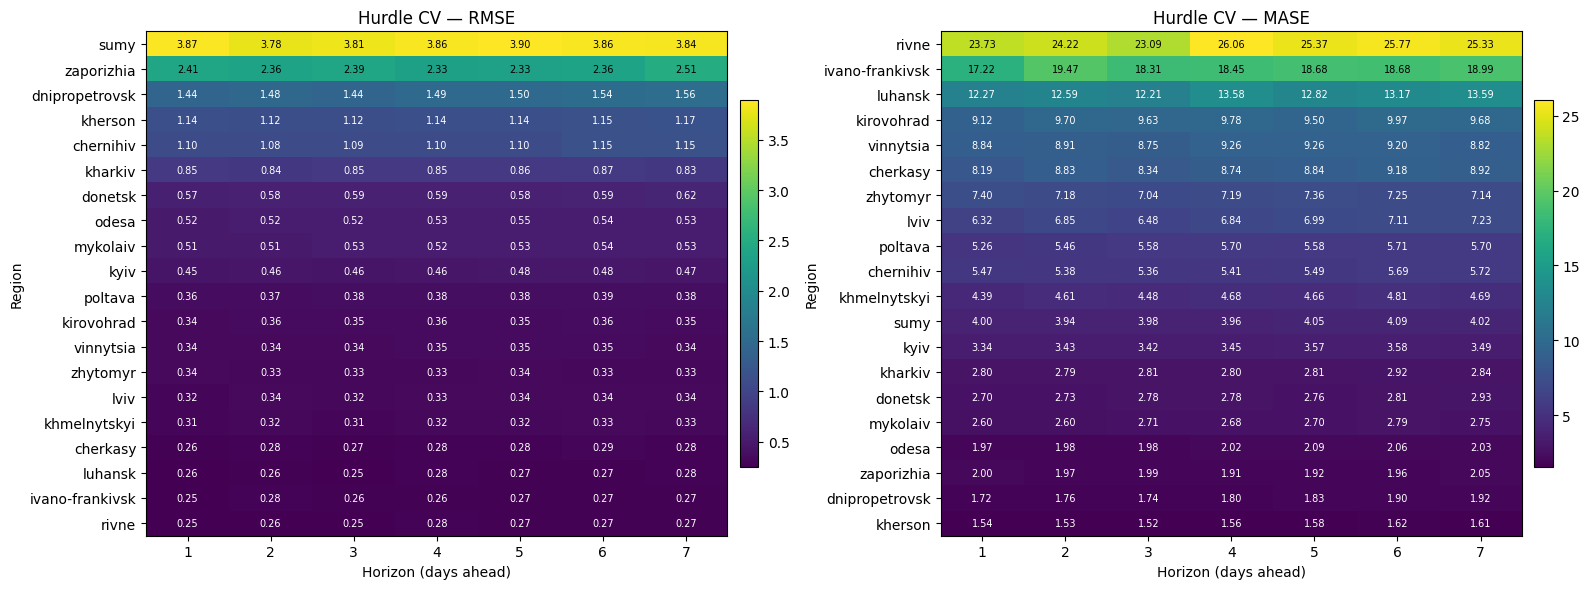


=== Classifier CV — Per-horizon ===


,horizon,F1,ROC_AUC,PR_AUC,Brier,n
0,1,0.650485,0.898163,0.723561,0.147996,1580
1,2,0.643787,0.897350,0.714475,0.149882,1580
2,3,0.649227,0.900371,0.726983,0.148254,1580
3,4,0.643110,0.902640,0.745548,0.150116,1580
4,5,0.644706,0.903288,0.736629,0.148328,1580
5,6,0.656398,0.910556,0.761031,0.147030,1580
6,7,0.649289,0.901886,0.736780,0.149558,1580


In [38]:
print("\n=== Hurdle CV — Per-region ===")
display(cv_results["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "n"]])

print("\n=== Hurdle CV — Per-horizon ===")
display(cv_results["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_region_horizon_heatmap(cv_results["per_region_horizon"], metric="RMSE",
                            title="Hurdle CV — RMSE", ax=axes[0])
plot_region_horizon_heatmap(cv_results["per_region_horizon"], metric="MASE",
                            title="Hurdle CV — MASE", ax=axes[1])
plt.tight_layout(); plt.show()

print("\n=== Classifier CV — Per-horizon ===")
display(cv_classif_results["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


## Classifier Calibration

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

_CAL_EPS = 1e-6

def _logit(p):
    p = np.clip(p, _CAL_EPS, 1 - _CAL_EPS)
    return np.log(p / (1 - p))

def fit_sigmoid_cal(y_prob, y_true):
    lr = LogisticRegression(C=1e6, solver="lbfgs")
    lr.fit(_logit(y_prob).reshape(-1, 1), np.asarray(y_true, dtype=int))
    return lr

def apply_sigmoid_cal(lr, y_prob):
    return lr.predict_proba(_logit(y_prob).reshape(-1, 1))[:, 1]

def _oof_one_group(y, p, method, n_splits, random_state):
    """OOF calibrated probs for one contiguous subset."""
    minority = int(min(np.bincount(y))) if set(y) == {0, 1} else 0
    n_splits_eff = max(2, min(n_splits, minority)) if minority >= 2 else 0
    if n_splits_eff < 2:
        return apply_sigmoid_cal(fit_sigmoid_cal(p, y), p)
    out = np.zeros_like(p)
    skf = StratifiedKFold(n_splits=n_splits_eff, shuffle=True, random_state=random_state)
    for fit_idx, eval_idx in skf.split(p, y):
            c = fit_sigmoid_cal(p[fit_idx], y[fit_idx])
            out[eval_idx] = apply_sigmoid_cal(c, p[eval_idx])
    return out


def oof_calibrated_probs(long_df, method, n_splits=5, random_state=RANDOM_STATE, group_col=None):
    """Returns (y_true, p_raw, p_calibrated) arrays aligned to long_df rows."""
    y = long_df["y_true"].to_numpy().astype(int)
    p = long_df["y_prob"].to_numpy().astype(float)
    if group_col is None:
        return y, p, _oof_one_group(y, p, method, n_splits, random_state)
    p_cal  = np.zeros_like(p)
    groups = long_df[group_col].to_numpy()
    for g in pd.unique(groups):
        mask = (groups == g)
        p_cal[mask] = _oof_one_group(y[mask], p[mask], method, n_splits, random_state)
    return y, p, p_cal


def fit_final_calibrators_per_horizon(long_df, method):
    """Fit one calibrator per horizon on all CV rows. Returns {horizon: calibrator}."""
    out = {}
    for h, sub in long_df.groupby("horizon"):
        y_h = sub["y_true"].to_numpy().astype(int)
        p_h = sub["y_prob"].to_numpy().astype(float)
        if len(np.unique(y_h)) < 2:
            out[int(h)] = None
            continue
        out[int(h)] = fit_sigmoid_cal(p_h, y_h)
    return out


def apply_calibrator_per_horizon(long_df, calibrators_per_h, method):
    """Apply per-horizon calibrator to y_prob column. Returns calibrated prob array."""
    p_raw = long_df["y_prob"].to_numpy().astype(float)
    out   = p_raw.copy()
    for h, sub in long_df.groupby("horizon"):
        cal = calibrators_per_h.get(int(h))
        if cal is None:
            continue
        idx   = sub.index.to_numpy()
        sub_p = sub["y_prob"].to_numpy().astype(float)
        out[idx] =apply_sigmoid_cal(cal, sub_p)
    return out


In [ ]:
# OOF calibration assessment — compare Brier before vs after each method
long_df_c_reset = long_df_c.reset_index(drop=True)

for method in ["sigmoid"]:
    y_true_cal, y_raw, y_cal = oof_calibrated_probs(long_df_c_reset, method=method, group_col="horizon")
    g_raw = _classif_metrics_hurdle(y_true_cal, y_raw)
    g_cal = _classif_metrics_hurdle(y_true_cal, y_cal)
    print(f"{method:10s}  Brier {g_raw['Brier']:.4f} -> {g_cal['Brier']:.4f} "
          f"| ROC-AUC {g_raw['ROC_AUC']:.4f} -> {g_cal['ROC_AUC']:.4f} "
          f"| PR-AUC {g_raw['PR_AUC']:.4f} -> {g_cal['PR_AUC']:.4f}")


isotonic    Brier 0.1487 -> 0.0897 | ROC-AUC 0.9020 -> 0.8962 | PR-AUC 0.7333 -> 0.7205
sigmoid     Brier 0.1487 -> 0.0902 | ROC-AUC 0.9020 -> 0.9011 | PR-AUC 0.7333 -> 0.7326


In [39]:
# --- Change CAL_METHOD here and re-run this cell + the next to reevaluate ---
CAL_METHOD = "sigmoid"   # or "isotonic"

calibrators = fit_final_calibrators_per_horizon(long_df_c_reset, method=CAL_METHOD)
print(f"Fitted {sum(c is not None for c in calibrators.values())}/{len(calibrators)} "
      f"per-horizon calibrators  (method={CAL_METHOD!r})")

# Apply calibration to CV classifier predictions
long_df_c_cal          = long_df_c_reset.copy()
long_df_c_cal["y_prob"] = apply_calibrator_per_horizon(long_df_c_reset, calibrators, method=CAL_METHOD)

# Reconstruct hurdle predictions with calibrated probs
long_df_h_cal           = long_df_h.reset_index(drop=True).copy()
long_df_h_cal["y_pred"] = long_df_c_cal["y_prob"].values * long_df_r.reset_index(drop=True)["y_pred"].values

cv_results_cal = evaluate_hurdle_long(long_df_h_cal, mae_scales, rmse_scales)
g_unc = cv_results["global"]
g_cal = cv_results_cal["global"]
print(f"\nHurdle after {CAL_METHOD} calibration:")
print(f"  RMSE  : {g_unc['RMSE']:.4f}  ->  {g_cal['RMSE']:.4f}")
print(f"  MAE   : {g_unc['MAE']:.4f}  ->  {g_cal['MAE']:.4f}")
print(f"  MASE  : {g_unc['MASE_mean']:.4f}  ->  {g_cal['MASE_mean']:.4f}")
print(f"  RMSSE : {g_unc['RMSSE_mean']:.4f}  ->  {g_cal['RMSSE_mean']:.4f}")
print(f"  R²    : {g_unc['R2']:.4f}  ->  {g_cal['R2']:.4f}")

print("\n=== Calibrated hurdle — Per-region ===")
display(cv_results_cal["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "n"]])

print("\n=== Calibrated Hurdle — Per-horizon ===")
display(cv_results_cal["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

cv_classif_results_cal = evaluate_classif_long(long_df_c_cal)
print("\n=== Calibrated Classifier — Per-horizon ===")
display(cv_classif_results_cal["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


Fitted 7/7 per-horizon calibrators  (method='sigmoid')

Hurdle after sigmoid calibration:
  RMSE  : 1.1848  ->  1.1472
  MAE   : 0.6886  ->  0.4814
  MASE  : 6.8233  ->  1.6580
  RMSSE : 1.4683  ->  0.9404
  R²    : 0.3754  ->  0.4144

=== Calibrated hurdle — Per-region ===


,region,RMSE,MAE,MASE,RMSSE,n
0,khmelnytskyi,0.111608,0.031972,0.468391,0.374665,553
1,luhansk,0.011001,0.009758,0.476503,0.066574,553
2,odesa,0.244028,0.179328,0.695936,0.434313,553
3,cherkasy,0.112569,0.025199,0.820365,0.642288,553
4,mykolaiv,0.279752,0.199845,1.036363,0.540471,553
5,kyiv,0.275644,0.148307,1.114204,0.568012,553
6,zhytomyr,0.191645,0.051082,1.151301,0.795622,553
7,lviv,0.249892,0.048546,1.185321,1.008207,553
8,donetsk,0.352213,0.251597,1.218480,0.430089,553
9,vinnytsia,0.160884,0.048145,1.282397,0.763792,553



=== Calibrated Hurdle — Per-horizon ===


,horizon,RMSE,MAE,MASE,RMSSE,R2,n
0,1,1.154359,0.477887,1.651332,0.940416,0.386114,1580
1,2,1.131042,0.475014,1.660449,0.936642,0.409621,1580
2,3,1.140681,0.476892,1.635952,0.937054,0.409079,1580
3,4,1.139541,0.474030,1.646398,0.940792,0.417484,1580
4,5,1.150770,0.482927,1.655779,0.933799,0.415111,1580
5,6,1.142711,0.486933,1.644609,0.937029,0.441645,1580
6,7,1.171177,0.496418,1.711152,0.952155,0.419102,1580



=== Calibrated Classifier — Per-horizon ===


,horizon,F1,ROC_AUC,PR_AUC,Brier,n
0,1,0.639175,0.898163,0.723561,0.090321,1580
1,2,0.627787,0.897350,0.714475,0.090804,1580
2,3,0.653199,0.900371,0.726983,0.090248,1580
3,4,0.665552,0.902640,0.745548,0.089664,1580
4,5,0.646667,0.903288,0.736629,0.090694,1580
5,6,0.673139,0.910556,0.761031,0.087792,1580
6,7,0.672185,0.901886,0.736780,0.090944,1580


## Final Test Set Evaluation

In [40]:
def run_final_test(predict_stride=1, retrain_stride=OUTPUT_CHUNK_LEN):
    """Evaluate hurdle model on the held-out test set.

    Makes a 7-day prediction every predict_stride days (default: every day).
    Retrains both models every retrain_stride days (default: every 7 days).
    Training always starts from 80% of the full series.
    """
    full_target_c = [tr.append(vl).append(te)
                     for tr, vl, te in zip(train_target_c, val_target_c, test_target_c)]
    full_target_r = [tr.append(vl).append(te)
                     for tr, vl, te in zip(train_target_r, val_target_r, test_target_r)]
    full_weights_final = make_positive_only_weights(full_target_r)

    ref_ts         = full_target_c[0]
    n_total        = len(ref_ts)
    test_start_idx = int(TRAIN_VAL_END * n_total)
    n_regions      = len(full_target_c)

    fold_preds_c = [[] for _ in range(n_regions)]
    fold_preds_r = [[] for _ in range(n_regions)]
    fold_preds_h = [[] for _ in range(n_regions)]
    n_preds    = 0
    n_retrains = 0
    clf = None
    reg = None

    for t0 in range(test_start_idx, n_total - OUTPUT_CHUNK_LEN + 1, predict_stride):
        steps_since_start = t0 - test_start_idx

        # --- Retrain every retrain_stride steps ---
        if steps_since_start % retrain_stride == 0:
            retrain_time  = ref_ts.time_index[t0]
            train_c       = [ts.drop_after(retrain_time) for ts in full_target_c]
            train_r       = [ts.drop_after(retrain_time) for ts in full_target_r]
            train_weights = [w.drop_after(retrain_time)  for w  in full_weights_final]

            clf = get_event_classifier()
            clf.fit(series=train_c, past_covariates=full_past_covs_c,
                    future_covariates=full_fut_covs_c)

            reg = get_count_regressor()
            reg.fit(series=train_r, past_covariates=full_past_covs_r,
                    future_covariates=full_fut_covs_r, sample_weight=train_weights)

            n_retrains += 1
            print(f"   retrain {n_retrains}  (data up to {retrain_time.date()})")

        # --- Daily prediction: growing context, frozen model ---
        split_time    = ref_ts.time_index[t0]
        pred_series_c = [ts.drop_after(split_time) for ts in full_target_c]
        pred_series_r = [ts.drop_after(split_time) for ts in full_target_r]

        preds_c = clf.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_c,
            past_covariates=full_past_covs_c, future_covariates=full_fut_covs_c,
            predict_likelihood_parameters=True, show_warnings=False,
        )
        preds_r = reg.predict(
            n=OUTPUT_CHUNK_LEN, series=pred_series_r,
            past_covariates=full_past_covs_r, future_covariates=full_fut_covs_r,
            show_warnings=False,
        )

        for r_idx, (pred_c, pred_r) in enumerate(zip(preds_c, preds_r)):
            prob_ts   = pred_c.univariate_component(pred_c.n_components - 1)
            hurdle_ts = TimeSeries.from_times_and_values(
                pred_r.time_index,
                (prob_ts.values().ravel() * pred_r.values().ravel()).reshape(-1, 1),
            )
            fold_preds_c[r_idx].append(prob_ts)
            fold_preds_r[r_idx].append(pred_r)
            fold_preds_h[r_idx].append(hurdle_ts)

        n_preds += 1

    print(f"   {n_preds} daily predictions, {n_retrains} retrains complete")
    return fold_preds_c, fold_preds_r, fold_preds_h, full_target_c, full_target_r


In [ ]:
print("Running final test evaluation (retrain every 7 days) ...")
test_preds_c, test_preds_r, test_preds_h, full_target_c, full_target_r = run_final_test()


Running final test evaluation (retrain every 7 days) ...


This model will treat target `series` lagged values as numeric input features (and not categorical).


   retrain 1  (data up to 2024-08-05)


In [ ]:
test_long_c = (
    collect_predictions_long(full_target_c, test_preds_c, region_names)
    .rename(columns={"y_pred": "y_prob"})
)
test_long_r = collect_predictions_long(full_target_r, test_preds_r, region_names)
test_long_h = collect_predictions_long(full_target_r, test_preds_h, region_names)

# Naive scales from the 80% training data (no test leakage)
mae_scales_test, rmse_scales_test = compute_naive_scales(
    [tr.append(vl) for tr, vl in zip(train_target_r, val_target_r)],
    region_names, seasonality=7,
)

test_results = evaluate_hurdle_long(test_long_h, mae_scales_test, rmse_scales_test)
g = test_results["global"]
print("=== Final Test — Global metrics ===")
print(f"  RMSE        : {g['RMSE']:.4f}")
print(f"  MAE         : {g['MAE']:.4f}")
print(f"  MASE (mean) : {g['MASE_mean']:.4f}")
print(f"  RMSSE (mean): {g['RMSSE_mean']:.4f}")
print(f"  R²          : {g['R2']:.4f}")
print(f"  n           : {g['n']:,}")

print("\n=== Final Test — Per-region ===")
display(test_results["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Final Test — Per-horizon ===")
display(test_results["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_region_horizon_heatmap(test_results["per_region_horizon"], metric="RMSE",
                            title="Final Test — RMSE", ax=axes[0])
plot_region_horizon_heatmap(test_results["per_region_horizon"], metric="MASE",
                            title="Final Test — MASE", ax=axes[1])
plt.tight_layout(); plt.show()

print("\n=== Final Test — Classifier standalone ===")
test_classif_results = evaluate_classif_long(test_long_c)
display(test_classif_results["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])


In [ ]:
# Apply the CV-fitted calibrators to the test predictions (no leakage: calibrators
# were fitted on validation-fold data, applied here to the held-out test set).
test_long_c_reset = test_long_c.reset_index(drop=True)
test_long_c_cal   = test_long_c_reset.copy()
test_long_c_cal["y_prob"] = apply_calibrator_per_horizon(
    test_long_c_reset, calibrators, method=CAL_METHOD
)

test_long_h_cal           = test_long_h.reset_index(drop=True).copy()
test_long_h_cal["y_pred"] = (
    test_long_c_cal["y_prob"].values
    * test_long_r.reset_index(drop=True)["y_pred"].values
)

test_results_cal = evaluate_hurdle_long(test_long_h_cal, mae_scales_test, rmse_scales_test)
g_unc = test_results["global"]
g_cal = test_results_cal["global"]

print(f"=== Final Test after {CAL_METHOD} calibration — Global metrics ===")
print(f"  RMSE  : {g_unc['RMSE']:.4f}  ->  {g_cal['RMSE']:.4f}")
print(f"  MAE   : {g_unc['MAE']:.4f}  ->  {g_cal['MAE']:.4f}")
print(f"  MASE  : {g_unc['MASE_mean']:.4f}  ->  {g_cal['MASE_mean']:.4f}")
print(f"  RMSSE : {g_unc['RMSSE_mean']:.4f}  ->  {g_cal['RMSSE_mean']:.4f}")
print(f"  R²    : {g_unc['R2']:.4f}  ->  {g_cal['R2']:.4f}")

print("\n=== Calibrated Final Test — Per-region ===")
display(test_results_cal["per_region"][["region", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

print("\n=== Calibrated Final Test — Per-horizon ===")
display(test_results_cal["per_horizon"][["horizon", "RMSE", "MAE", "MASE", "RMSSE", "R2", "n"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_region_horizon_heatmap(test_results_cal["per_region_horizon"], metric="RMSE",
                            title="Final Test (calibrated) — RMSE", ax=axes[0])
plot_region_horizon_heatmap(test_results_cal["per_region_horizon"], metric="MASE",
                            title="Final Test (calibrated) — MASE", ax=axes[1])
plt.tight_layout(); plt.show()

print("\n=== Calibrated Final Test — Classifier ===")
test_classif_results_cal = evaluate_classif_long(test_long_c_cal)
display(test_classif_results_cal["per_horizon"][["horizon", "F1", "ROC_AUC", "PR_AUC", "Brier", "n"]])
